In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ---------------------------------------------------------
# LOAD DATASET
# ---------------------------------------------------------

df = pd.read_csv("../processed_data/spotify_ml_ready.csv")

print(df.shape)

df.head()

(363142, 28)


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,...,genre_Folk,genre_Hip-Hop,genre_Jazz,genre_Pop,genre_R&B,genre_Rock,era_classic,era_early_streaming,era_modern,era_retro
0,0.735,0.478,2,-12.472,1,0.0293,0.1890,0.000002,0.3550,0.947,...,0,0,0,1,0,0,0,0,0,1
1,0.336,0.627,7,-7.463,1,0.0384,0.1640,0.000000,0.0708,0.350,...,0,0,0,1,0,0,0,0,0,1
2,0.598,0.470,8,-8.744,1,0.0496,0.6170,0.000000,0.5050,0.879,...,0,0,0,1,0,0,1,0,0,0
3,0.754,0.424,2,-8.463,1,0.0363,0.6430,0.000000,0.0652,0.806,...,0,0,0,1,0,0,1,0,0,0
4,0.525,0.621,7,-7.364,1,0.1170,0.0489,0.000000,0.2910,0.592,...,0,0,0,1,0,0,0,0,1,0


In [3]:
# ---------------------------------------------------------
# CREATE POPULARITY BINS (IF NOT ALREADY PRESENT)
# ---------------------------------------------------------

low_cut = df["popularity"].quantile(0.40)
high_cut = df["popularity"].quantile(0.90)

def bin_popularity(x):
    if x < low_cut:
        return "low"
    elif x < high_cut:
        return "medium"
    else:
        return "high"

df["popularity_bin"] = df["popularity"].apply(bin_popularity)

print(df["popularity_bin"].value_counts())


popularity_bin
medium    186955
low       138950
high       37237
Name: count, dtype: int64


In [4]:
# ---------------------------------------------------------
# ENCODE TARGET LABELS
# ---------------------------------------------------------

le = LabelEncoder()

df["target"] = le.fit_transform(df["popularity_bin"])

print(le.classes_)

['high' 'low' 'medium']


In [5]:
# ---------------------------------------------------------
# DEFINE FEATURE COLUMNS
# ---------------------------------------------------------

FEATURES = [

    # Audio features
    "danceability",
    "energy",
    "loudness",
    "valence",
    "tempo",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "key",
    "mode",
    "duration_ms",

    # Artist popularity
    "avg_artist_popularity"
    
]

In [6]:
# ---------------------------------------------------------
# ADD GENRE + ERA FEATURES
# ---------------------------------------------------------

genre_cols = [c for c in df.columns if c.startswith("genre_")]
era_cols = [c for c in df.columns if c.startswith("era_")]

FEATURES += genre_cols + era_cols

print(FEATURES)

['danceability', 'energy', 'loudness', 'valence', 'tempo', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'key', 'mode', 'duration_ms', 'avg_artist_popularity', 'genre_Blues', 'genre_Classical', 'genre_Country', 'genre_Electronic', 'genre_Folk', 'genre_Hip-Hop', 'genre_Jazz', 'genre_Pop', 'genre_R&B', 'genre_Rock', 'era_classic', 'era_early_streaming', 'era_modern', 'era_retro']


In [7]:
# ---------------------------------------------------------
# CREATE X AND y
# ---------------------------------------------------------

X = df[FEATURES]

y = df["target"]

In [8]:
from sklearn.preprocessing import StandardScaler
import joblib
import os

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

BASE_DIR = os.path.dirname(os.getcwd())  # go from notebooks → project root

scaler_path = os.path.join(BASE_DIR, "models", "scaler.pkl")

joblib.dump(scaler, scaler_path)

['e:\\spotify-popularity-predictor\\models\\scaler.pkl']

In [9]:
# ---------------------------------------------------------
# TRAIN/TEST SPLIT
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(290513, 27)
(72629, 27)


In [10]:
# ---------------------------------------------------------
# TRAIN RANDOM FOREST
# ---------------------------------------------------------

model = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

import os
os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/spotify_popularity_model.pkl")

['../models/spotify_popularity_model.pkl']

In [11]:
# ---------------------------------------------------------
# PREDICTIONS
# ---------------------------------------------------------

preds = model.predict(X_test)

In [12]:
# ---------------------------------------------------------
# EVALUATION
# ---------------------------------------------------------

print("Accuracy:")
print(accuracy_score(y_test, preds))

print("\nClassification Report:")
print(classification_report(y_test, preds))

Accuracy:
0.6439025733522422

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.12      0.20      7448
           1       0.70      0.54      0.61     27790
           2       0.62      0.82      0.71     37391

    accuracy                           0.64     72629
   macro avg       0.67      0.49      0.51     72629
weighted avg       0.66      0.64      0.62     72629



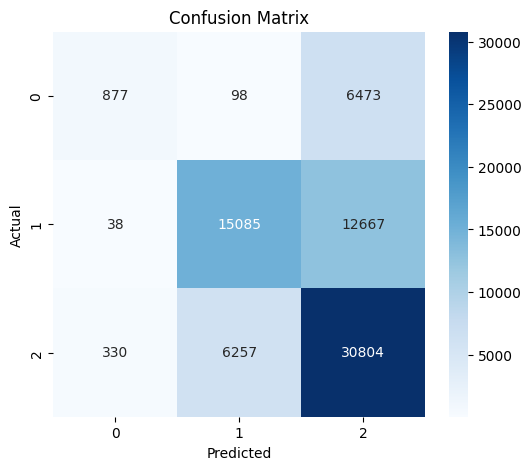

In [13]:
# ---------------------------------------------------------
# CONFUSION MATRIX
# ---------------------------------------------------------

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
# ---------------------------------------------------------
# FEATURE IMPORTANCE
# ---------------------------------------------------------

importance_df = pd.DataFrame({

    "feature": FEATURES,
    "importance": model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

print(importance_df.head(15))

                  feature  importance
12  avg_artist_popularity    0.451193
0            danceability    0.051862
2                loudness    0.047629
8                liveness    0.046294
24    era_early_streaming    0.045945
6            acousticness    0.044033
11            duration_ms    0.043782
7        instrumentalness    0.038257
1                  energy    0.034620
3                 valence    0.033331
5             speechiness    0.032477
4                   tempo    0.028926
18          genre_Hip-Hop    0.016811
25             era_modern    0.013752
9                     key    0.013570
